<a href="https://colab.research.google.com/github/hdflorez/Entrega_4/blob/main/Ej1_Student_Grade_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de Datos | 190304018-1 | 2026-1** | **Entrega 4** |

**Integrantes - Equipo 8:**
*   Mariana Villegas Ochoa
*   Melisa Colorado Soto
*   Jaider Santiago Villa David
*   Hernán Darío Flórez Martínez
---

# **Dataset: Student Grade Prediction**
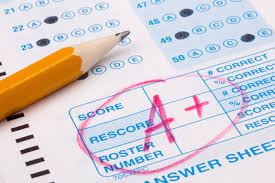

Recuperado de Kaggle: https://www.kaggle.com/datasets/dipam7/student-grade-prediction



---
##**Descripción del problema**
A partir de características académicas y personales de estudiantes contenidas en el dataset (hábitos de estudio, asistencia, antecedentes familiares, entre otras), se construye un modelo de clasificación multiclase que predice el nivel de rendimiento académico: Alto, Medio o Bajo.


# **1. Configuración inicial**





In [5]:
#Instalación de dependencias y descarga del dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

#Ruta de acceso al archivo
file_path = "student-mat.csv"

#Cargar la última versión del dataset
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "dipam7/student-grade-prediction",
  file_path,
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'student-grade-prediction' dataset.
First 5 records:   school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 c

In [6]:
#Importe de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [17]:
#Primera revisión del dataset

#Dimensiones del dataset
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones: 395 filas × 33 columnas


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [21]:
#Composición de dataset
print("\nTipos de datos:\n")
print(df.dtypes)
print("\nValores nulos:\n")
print(df.isnull().sum())
print("\nEstadísticas descriptivas:\n")
df.describe(include='all')


Tipos de datos:

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Valores nulos:

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
fa

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,...,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,...,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,...,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,...,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000


# **2. Anáñisis Exploratorio de Datos (EDA)**
En esta sección, se analizan distribuciones univariadas, correlaciones entre variables numéricas y patrones por subgrupos relevantes.



Distribución de clases:

rendimiento
Medio    192
Bajo     130
Alto      73
Name: count, dtype: int64


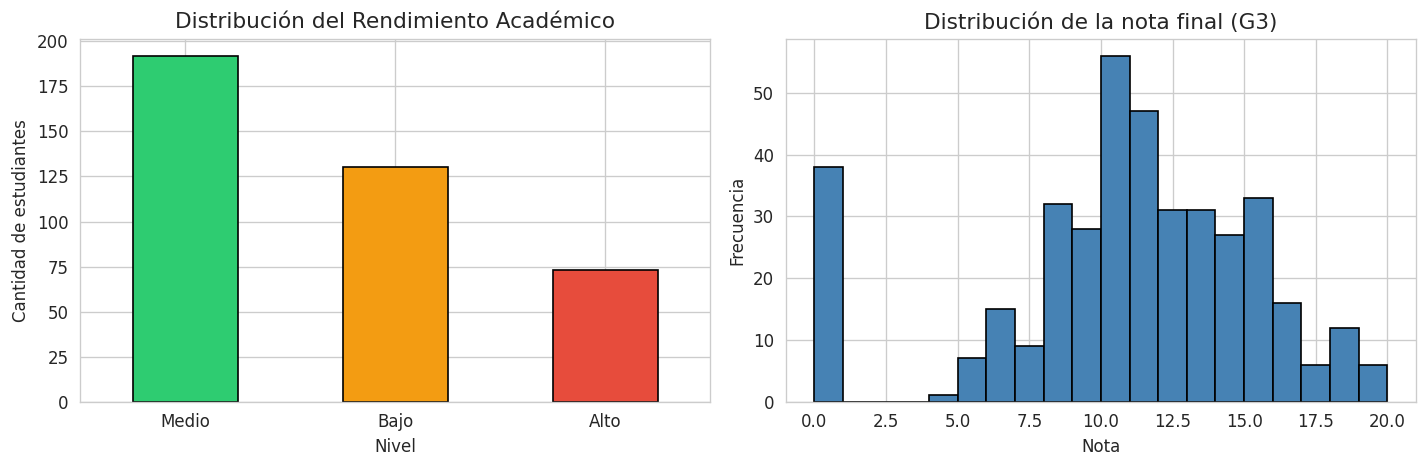

In [23]:
#Construcción de la variable objetivo

#La columna de nota final suele ser 'G3' (0-20).
#Definición: Alto ≥ 15, Medio 10-14, Bajo < 10

target_col = 'G3'

def clasificar_rendimiento(nota):
    if nota >= 15:
        return 'Alto'
    elif nota >= 10:
        return 'Medio'
    else:
        return 'Bajo'

df['rendimiento'] = df[target_col].apply(clasificar_rendimiento)
print("\nDistribución de clases:\n")
print(df['rendimiento'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['rendimiento'].value_counts().plot(kind='bar', ax=axes[0],
    color=['#2ecc71','#f39c12','#e74c3c'], edgecolor='black')
axes[0].set_title('Distribución del Rendimiento Académico', fontsize=13)
axes[0].set_xlabel('Nivel'); axes[0].set_ylabel('Cantidad de estudiantes')
axes[0].tick_params(axis='x', rotation=0)

df[target_col].hist(bins=20, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title(f'Distribución de la nota final ({target_col})', fontsize=13)
axes[1].set_xlabel('Nota'); axes[1].set_ylabel('Frecuencia')
plt.tight_layout(); plt.show()


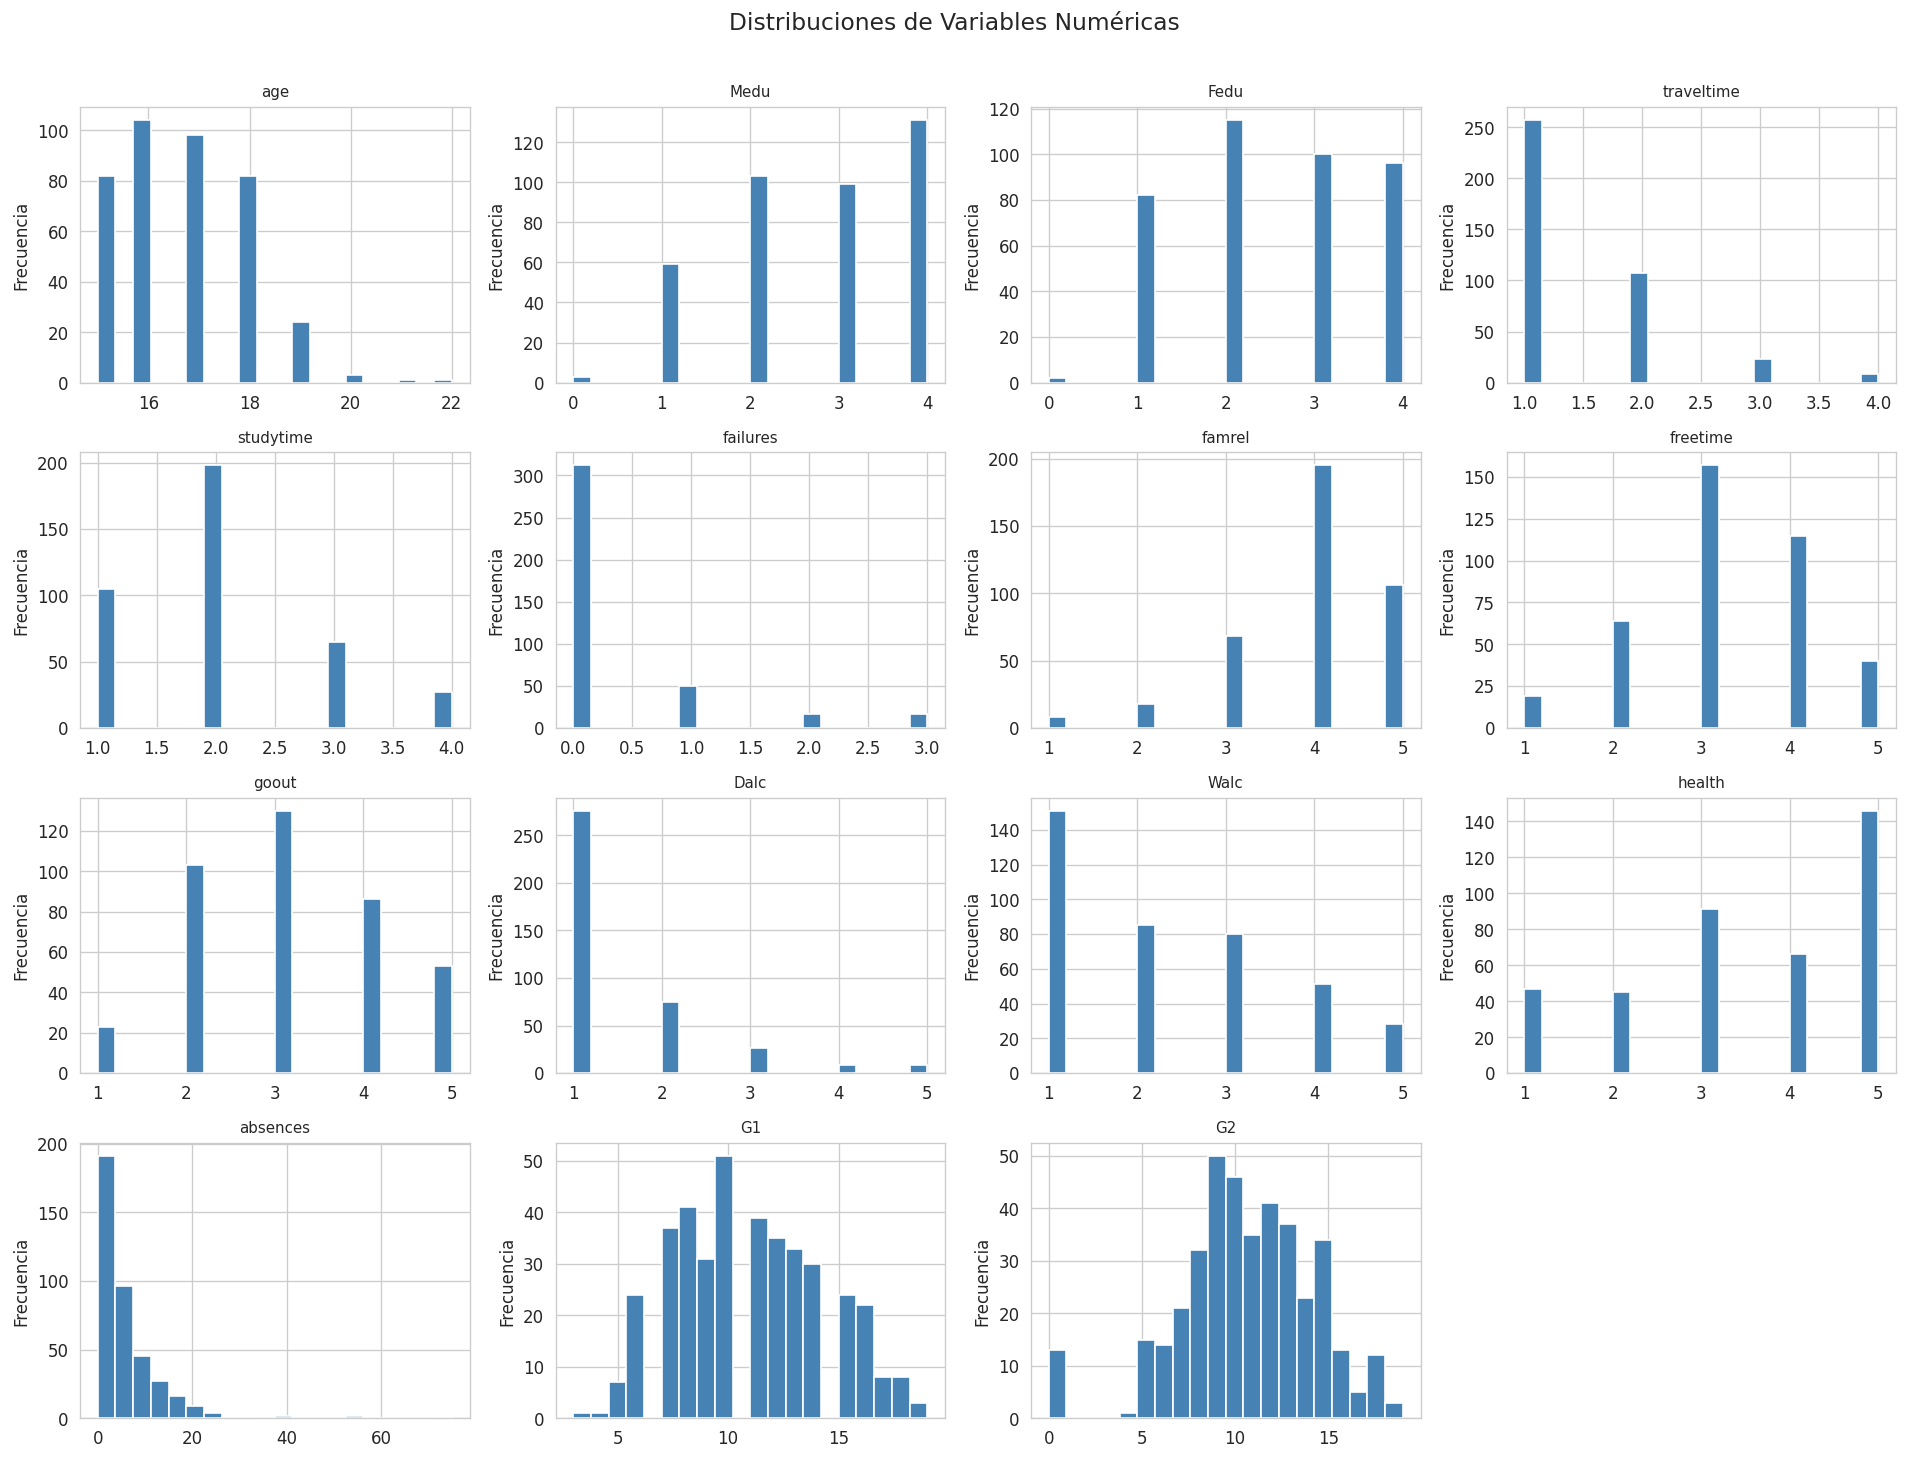

In [24]:
#Distribuciones de variables numéricas
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in [target_col]]

n = len(num_cols)
cols_plot = 4
rows_plot = (n + cols_plot - 1) // cols_plot

fig, axes = plt.subplots(rows_plot, cols_plot, figsize=(16, rows_plot * 3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel('Frecuencia')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribuciones de Variables Numéricas', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

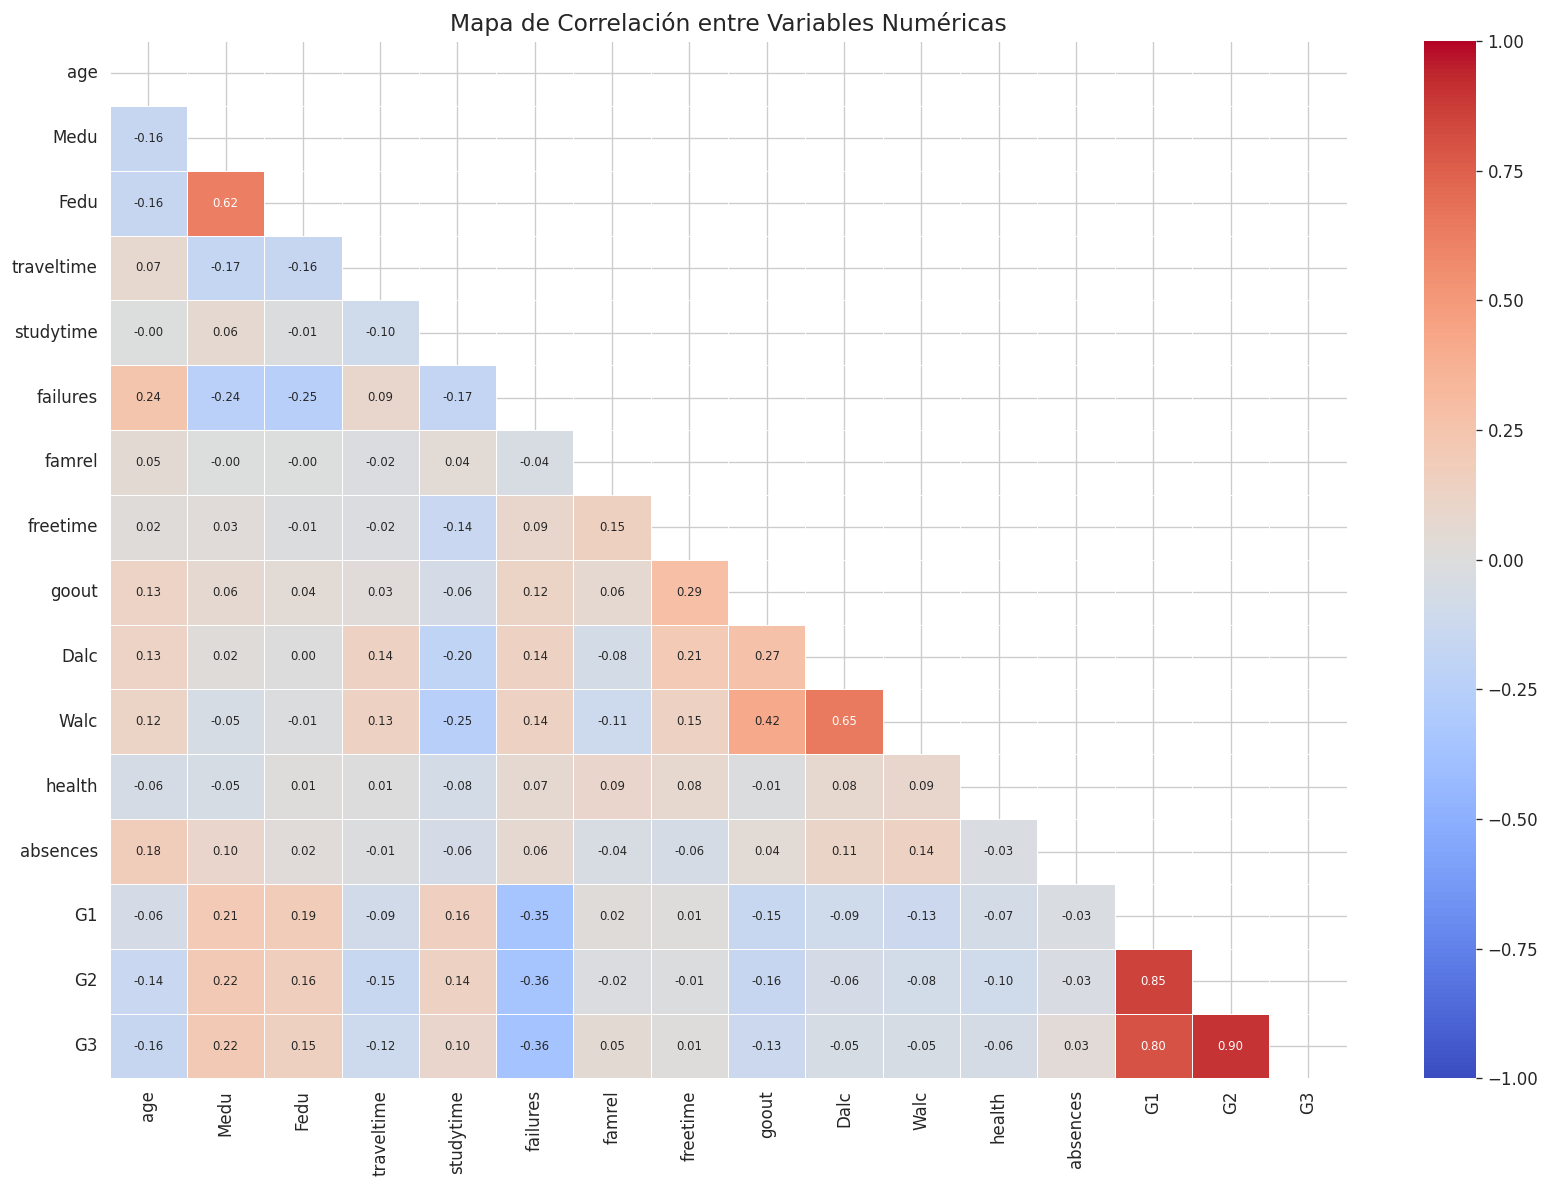


Correlación con la nota final (G3):

G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


In [26]:
#Mapa de correlación

plt.figure(figsize=(14, 10))
corr = df[num_cols + [target_col]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Mapa de Correlación entre Variables Numéricas', fontsize=14)
plt.tight_layout(); plt.show()

# Variables más correlacionadas con G3
print("\nCorrelación con la nota final (G3):\n")
print(corr[target_col].sort_values(ascending=False).drop(target_col))

Variables categóricas: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason']


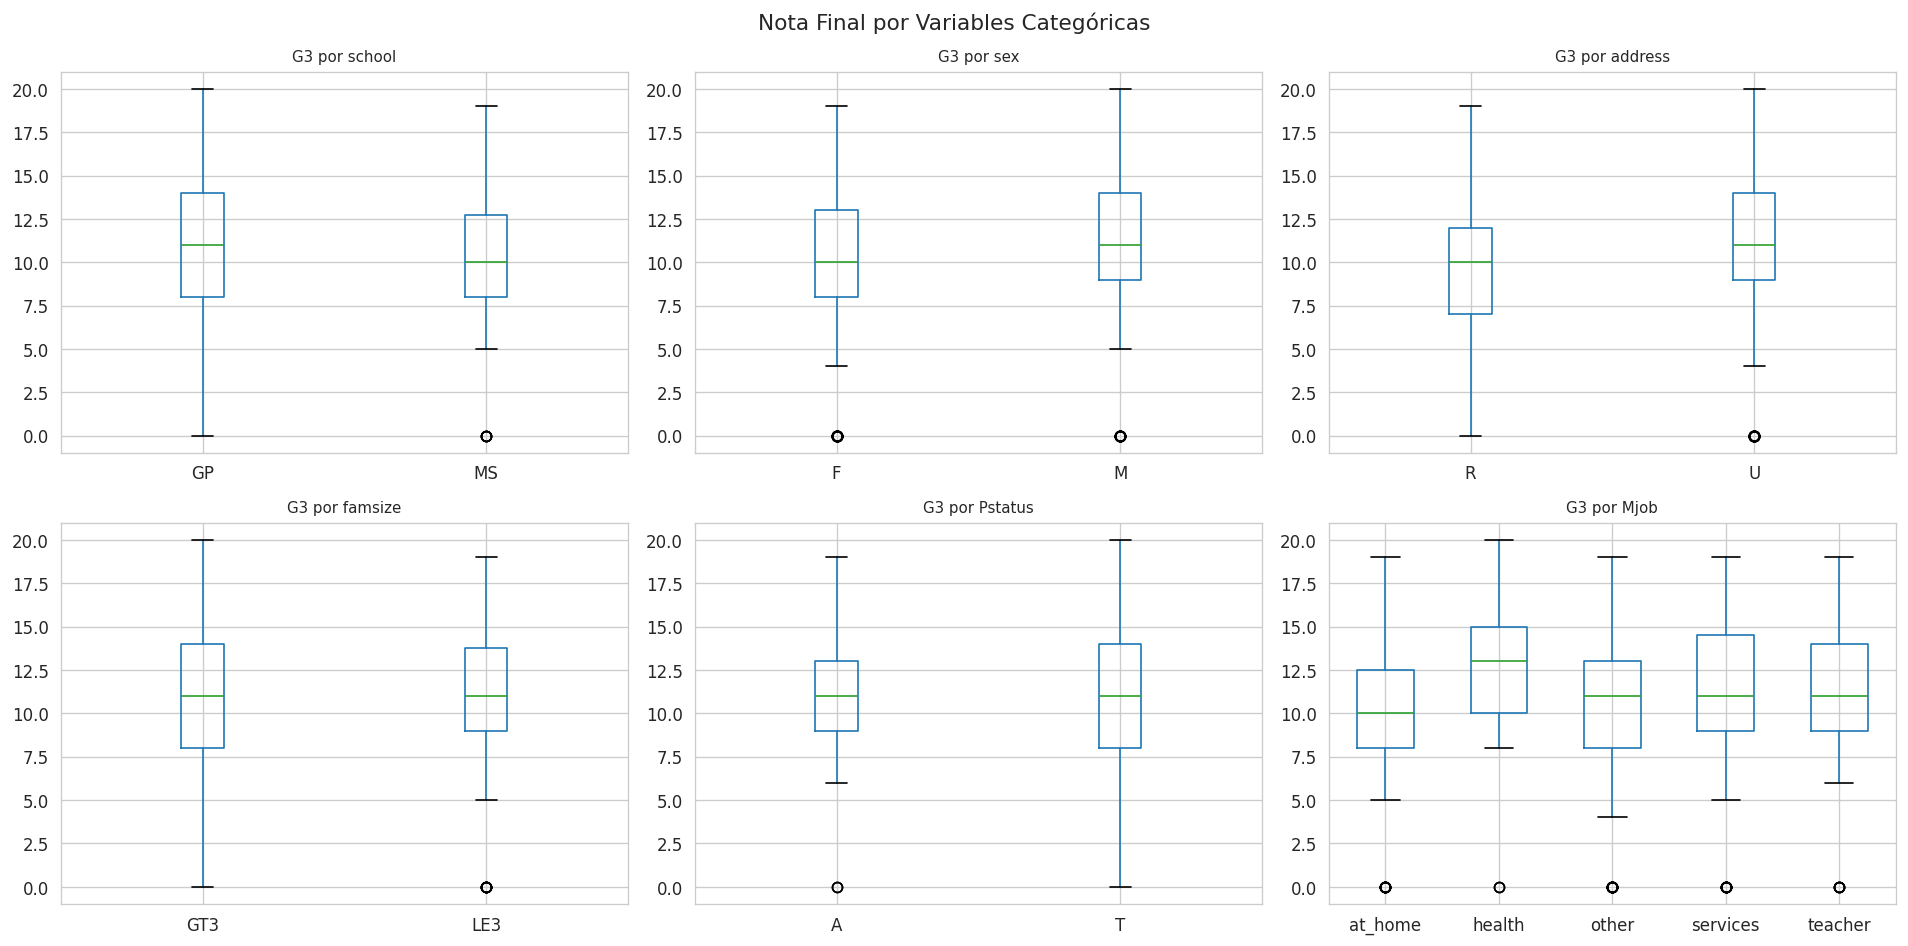

In [27]:
#Análisis por subgrupos categóricos

cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'rendimiento']
print("Variables categóricas:", cat_cols[:8])

# Boxplots: nota final vs variables categóricas más relevantes

cols_to_plot = cat_cols[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(cols_to_plot):
    df.boxplot(column=target_col, by=col, ax=axes[i])
    axes[i].set_title(f'{target_col} por {col}', fontsize=9)
    axes[i].set_xlabel('')
plt.suptitle('Nota Final por Variables Categóricas', fontsize=13)
plt.tight_layout(); plt.show()

<Figure size 960x600 with 0 Axes>

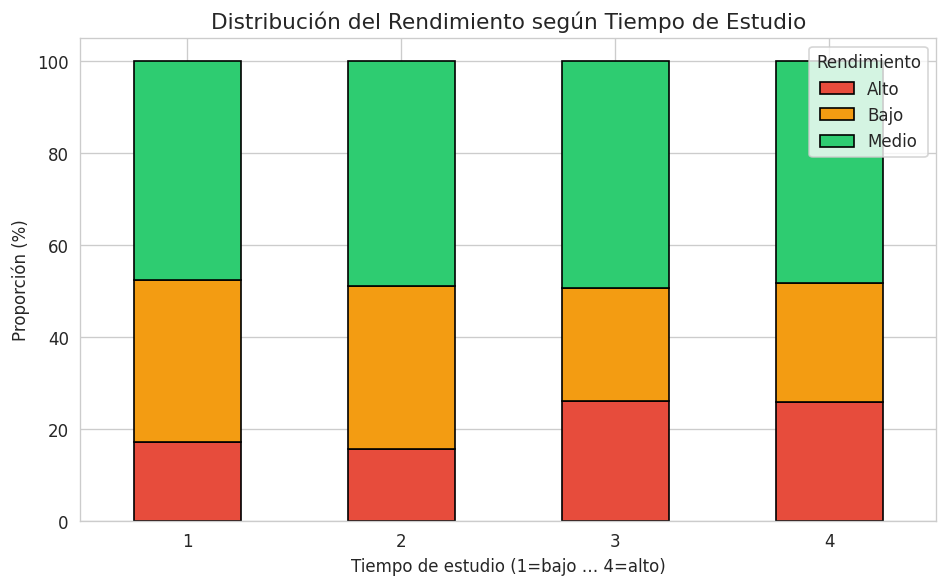

In [28]:
#Análisis de subgrupo: hábitos de estudio vs rendimiento
#studytime es la variable de hábitos de estudio en el dataset

if 'studytime' in df.columns:
    plt.figure(figsize=(8, 5))
    ct = pd.crosstab(df['studytime'], df['rendimiento'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, color=['#e74c3c','#f39c12','#2ecc71'],
            edgecolor='black', figsize=(8, 5))
    plt.title('Distribución del Rendimiento según Tiempo de Estudio', fontsize=13)
    plt.xlabel('Tiempo de estudio (1=bajo … 4=alto)')
    plt.ylabel('Proporción (%)')
    plt.legend(title='Rendimiento')
    plt.xticks(rotation=0)
    plt.tight_layout(); plt.show()

# **3. Procesamiento de datos texto del vínculo**

In [29]:
#Separar features y target
# Eliminar columnas de notas intermedias para evitar fuga de datos
drop_cols = [c for c in ['G1', 'G2', target_col, 'rendimiento'] if c in df.columns]
X_raw = df.drop(columns=drop_cols)
y_raw = df['rendimiento']

print("Shape X:", X_raw.shape)
print("Clases:", y_raw.value_counts().to_dict())

#Identificación de columnas numéricas y categóricas
num_features = X_raw.select_dtypes(include=np.number).columns.tolist()
cat_features = X_raw.select_dtypes(include='object').columns.tolist()
print(f"\nNúmericas ({len(num_features)}): {num_features}")
print(f"Categóricas ({len(cat_features)}): {cat_features}")

Shape X: (395, 30)
Clases: {'Medio': 192, 'Bajo': 130, 'Alto': 73}

Númericas (13): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Categóricas (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [30]:
#Imputación, codificación y estandarización
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

#Pipeline para columnas numéricas: imputar con mediana + estandarizar
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#Pipeline para columnas categóricas: imputar con moda + OHE
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Codificar etiquetas
le = LabelEncoder()
y = le.fit_transform(y_raw)
classes = le.classes_
print("Clases codificadas:", dict(zip(range(len(classes)), classes)))

# Split estratificado 80/20
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

# Ajustar preprocesador en train y transformar ambos
X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)

print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

Clases codificadas: {0: 'Alto', 1: 'Bajo', 2: 'Medio'}

Train: (316, 56) | Test: (79, 56)


In [32]:
#Verificar balance de clases
unique, counts = np.unique(y_train, return_counts=True)
print("\nBalance en train:\n")
for u, c in zip(unique, counts):
    print(f"  {classes[u]}: {c} ({c/len(y_train)*100:.1f}%)")


Balance en train:

  Alto: 58 (18.4%)
  Bajo: 104 (32.9%)
  Medio: 154 (48.7%)


# **4. Entrenamiento y Evaluación de Modelos**

Aplicamos tres algoritmos supervisados de clasificación:

1. **Regresión Logística**: modelo lineal de referencia, interpretable y eficiente.
2. **K-Nearest Neighbors (KNN)**: clasificador basado en similitud local, no paramétrico.
3. **Random Forest**: conjunto de árboles de decisión, robusto ante ruido y alta dimensionalidad.

### **Justificación de algoritmos**
- **Regresión Logística:** Excelente como baseline; asume separabilidad lineal entre clases. Útil cuando las relaciones entre variables y rendimiento son aproximadamente lineales (por ejemplo, asistencia, tiempo de estudio).
- **KNN:** No hace suposiciones sobre la distribución de datos. Captura patrones locales, pero es sensible a la escala (ya normalizada) y al parámetro k.
- **Random Forest:** Maneja bien variables categóricas y numéricas, resiste el sobreajuste mediante bagging y permite calcular importancia de características, clave para interpretabilidad pedagógica.

In [34]:
#Función auxiliar para evaluar y visualizar resultados
def evaluar_modelo(nombre, y_true, y_pred, clases):
    acc   = accuracy_score(y_true, y_pred)
    f1    = f1_score(y_true, y_pred, average='weighted')
    prec  = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"\n{'='*50}")
    print(f"  {nombre}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print("\n", classification_report(y_true, y_pred, target_names=clases))
    return {'Modelo': nombre, 'Accuracy': acc, 'F1-Score': f1,
            'Precision': prec, 'Recall': rec}

def plot_cm(nombre, y_true, y_pred, clases):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=clases)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Matriz de Confusión — {nombre}', fontsize=11)
    plt.tight_layout(); plt.show()

resultados = []


  Regresión Logística
  Accuracy : 0.4177
  F1-Score : 0.4301
  Precision: 0.4987
  Recall   : 0.4177

               precision    recall  f1-score   support

        Alto       0.25      0.60      0.35        15
        Bajo       0.61      0.42      0.50        26
       Medio       0.52      0.34      0.41        38

    accuracy                           0.42        79
   macro avg       0.46      0.46      0.42        79
weighted avg       0.50      0.42      0.43        79



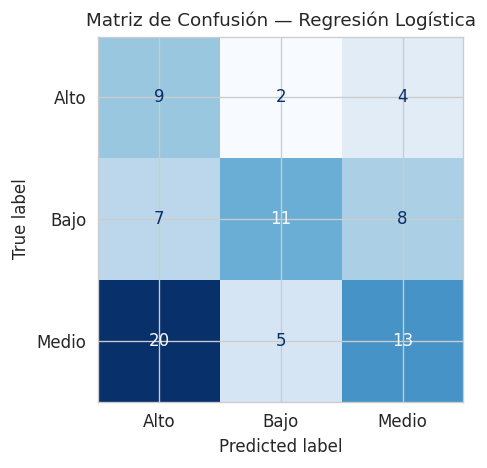

In [35]:
#Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                        class_weight='balanced', C=1.0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

res = evaluar_modelo("Regresión Logística", y_test, y_pred_lr, classes)
resultados.append(res)
plot_cm("Regresión Logística", y_test, y_pred_lr, classes)

Mejor k = 9


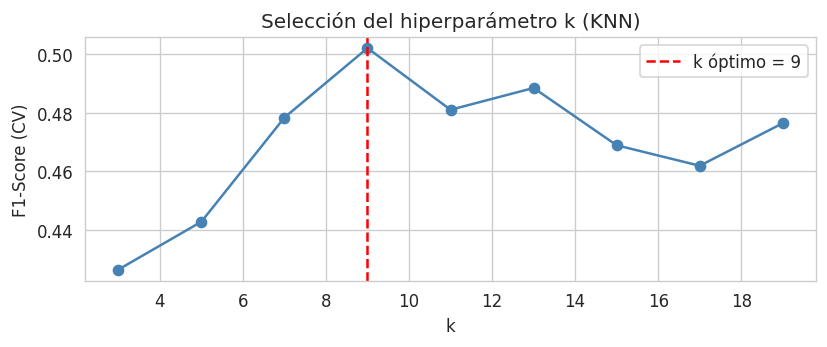


  KNN
  Accuracy : 0.4810
  F1-Score : 0.4763
  Precision: 0.4761
  Recall   : 0.4810

               precision    recall  f1-score   support

        Alto       0.44      0.47      0.45        15
        Bajo       0.43      0.35      0.38        26
       Medio       0.52      0.58      0.55        38

    accuracy                           0.48        79
   macro avg       0.46      0.46      0.46        79
weighted avg       0.48      0.48      0.48        79



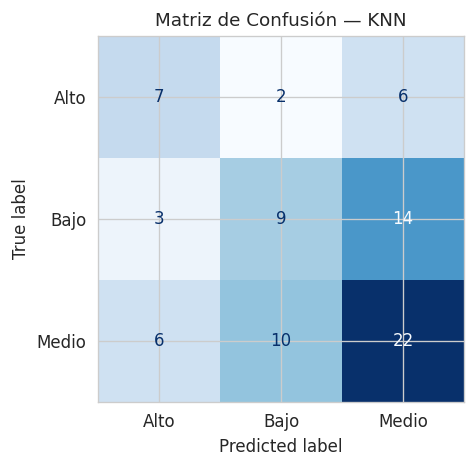

In [36]:
#Nearest Neighbors
# Selección de k óptimo mediante validación cruzada
k_scores = []
for k in range(3, 20, 2):
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn_cv, X_train, y_train, cv=5,
                            scoring='f1_weighted').mean()
    k_scores.append((k, score))

best_k = max(k_scores, key=lambda x: x[1])[0]
print(f"Mejor k = {best_k}")

plt.figure(figsize=(7, 3))
ks, scores = zip(*k_scores)
plt.plot(ks, scores, marker='o', color='steelblue')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'k óptimo = {best_k}')
plt.xlabel('k'); plt.ylabel('F1-Score (CV)')
plt.title('Selección del hiperparámetro k (KNN)')
plt.legend(); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

res = evaluar_modelo("KNN", y_test, y_pred_knn, classes)
resultados.append(res)
plot_cm("KNN", y_test, y_pred_knn, classes)


  Random Forest
  Accuracy : 0.5443
  F1-Score : 0.4925
  Precision: 0.5535
  Recall   : 0.5443

               precision    recall  f1-score   support

        Alto       0.50      0.13      0.21        15
        Bajo       0.62      0.31      0.41        26
       Medio       0.53      0.87      0.66        38

    accuracy                           0.54        79
   macro avg       0.55      0.44      0.43        79
weighted avg       0.55      0.54      0.49        79



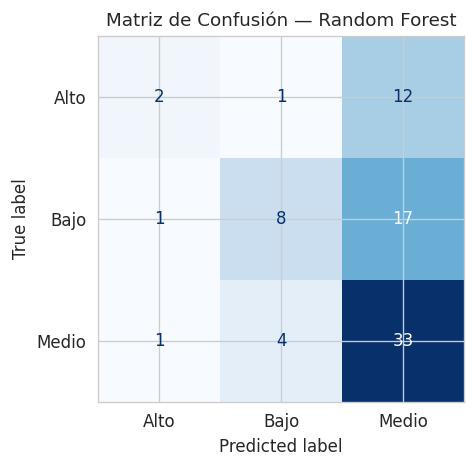

In [37]:
#Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                            class_weight='balanced', random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

res = evaluar_modelo("Random Forest", y_test, y_pred_rf, classes)
resultados.append(res)
plot_cm("Random Forest", y_test, y_pred_rf, classes)